# Nova Mart – FMCG Promotional Campaign Analysis
**Client:** Nova Mart  
**Analyst:** Data Analytics Team  
**Date:** June 2026

---
> **Setup:** Place this notebook inside your `resources_2` folder (same level as the `datasets` folder).
> Then run all cells top to bottom — data loads automatically from `datasets/`.
> If your notebook is elsewhere, just change `DATA_DIR` in Cell 2 to the correct relative path.

In [1]:
# ─────────────────────────────────────────────
# Cell 1 │ Imports & Style Configuration
# ─────────────────────────────────────────────
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Charts output folder (created next to this notebook) ──
OUTPUT_DIR = os.path.join(os.getcwd(), 'charts')
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Global style
plt.rcParams.update({
    'figure.dpi': 130,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
})

BRAND_COLOR   = '#1B3A6B'   # deep navy
ACCENT_COLOR  = '#E8612C'   # warm orange
PALETTE       = ['#1B3A6B','#E8612C','#2E8B57','#D4AF37','#8B1A4A','#4682B4']
print(f'✅ Libraries loaded | Charts → {OUTPUT_DIR}')

✅ Libraries loaded | Charts → /Users/awaisshah228/Documents/data-scient-bootcamp/internship/virtual-intern-1/resources_2/charts


In [2]:
# ─────────────────────────────────────────────
# Cell 2 │ Data Loading
# ─────────────────────────────────────────────

# ── Load CSVs from the datasets folder ──
# Update DATA_DIR if your folder is in a different location
DATA_DIR = 'datasets'   # e.g. 'resources_2/datasets' if run from project root

dim_campaigns = pd.read_csv(os.path.join(DATA_DIR, 'dim_campaigns.csv'))
dim_products  = pd.read_csv(os.path.join(DATA_DIR, 'dim_products.csv'))
dim_stores    = pd.read_csv(os.path.join(DATA_DIR, 'dim_stores.csv'))
fact_events   = pd.read_csv(os.path.join(DATA_DIR, 'fact_events.csv'))

print('✅ CSVs loaded:')
print(f'   dim_campaigns : {dim_campaigns.shape}')
print(f'   dim_products  : {dim_products.shape}')
print(f'   dim_stores    : {dim_stores.shape}')
print(f'   fact_events   : {fact_events.shape}')

# ── Standardise column names (strip spaces) ──
for _df in [dim_campaigns, dim_products, dim_stores, fact_events]:
    _df.columns = _df.columns.str.strip()

# ── Merge all tables into one working dataframe ──
df = (fact_events
      .merge(dim_stores,    on='store_id')
      .merge(dim_products,  on='product_code')
      .merge(dim_campaigns, on='campaign_id'))

# ── Computed metrics ──
df['revenue_before'] = df['base_price(before_promo)'] * df['quantity_sold(before_promo)']
df['revenue_after']  = df['base_price(after_promo)']  * df['quantity_sold(after_promo)']
df['IR%']  = (df['revenue_after']  - df['revenue_before'])  / df['revenue_before']  * 100
df['ISU%'] = (df['quantity_sold(after_promo)'] - df['quantity_sold(before_promo)']) / df['quantity_sold(before_promo)'] * 100

print(f'\n✅ Master dataframe ready │ {len(df):,} rows │ {df["city"].nunique()} cities │ {df["category"].nunique()} categories')
df.head(3)

✅ CSVs loaded:
   dim_campaigns : (2, 4)
   dim_products  : (15, 3)
   dim_stores    : (50, 2)
   fact_events   : (1500, 9)

✅ Master dataframe ready │ 1,500 rows │ 10 cities │ 5 categories


,event_id,store_id,campaign_id,product_code,base_price(before_promo),quantity_sold(before_promo),promo_type,base_price(after_promo),quantity_sold(after_promo),city,product_name,category,campaign_name,start_date,end_date,revenue_before,revenue_after,IR%,ISU%
0,8481be,STCHE-1,CAMP_DIW_01,P04,290,327.0,25% OFF,217,287,Chennai,Atliq_Farm_Chakki_Atta (1KG),Grocery & Staples,Diwali,12-11-2023,18-11-2023,94830.0,62279,-34.325635,-12.232416
1,20618e,STCHE-3,CAMP_SAN_01,P04,370,379.0,BOGOF,185,1622,Chennai,Atliq_Farm_Chakki_Atta (1KG),Grocery & Staples,Sankranti,10-01-2024,16-01-2024,140230.0,300070,113.984169,327.968338
2,f30579,STBLR-9,CAMP_DIW_01,P02,860,337.0,33% OFF,576,488,Bengaluru,Atliq_Sonamasuri_Rice (10KG),Grocery & Staples,Diwali,12-11-2023,18-11-2023,289820.0,281088,-3.012905,44.807122


---
## Q1 │ Number of Stores per City
**Business Question:** Which city has the most stores, and how does Bengaluru compare with Hyderabad and Chennai?

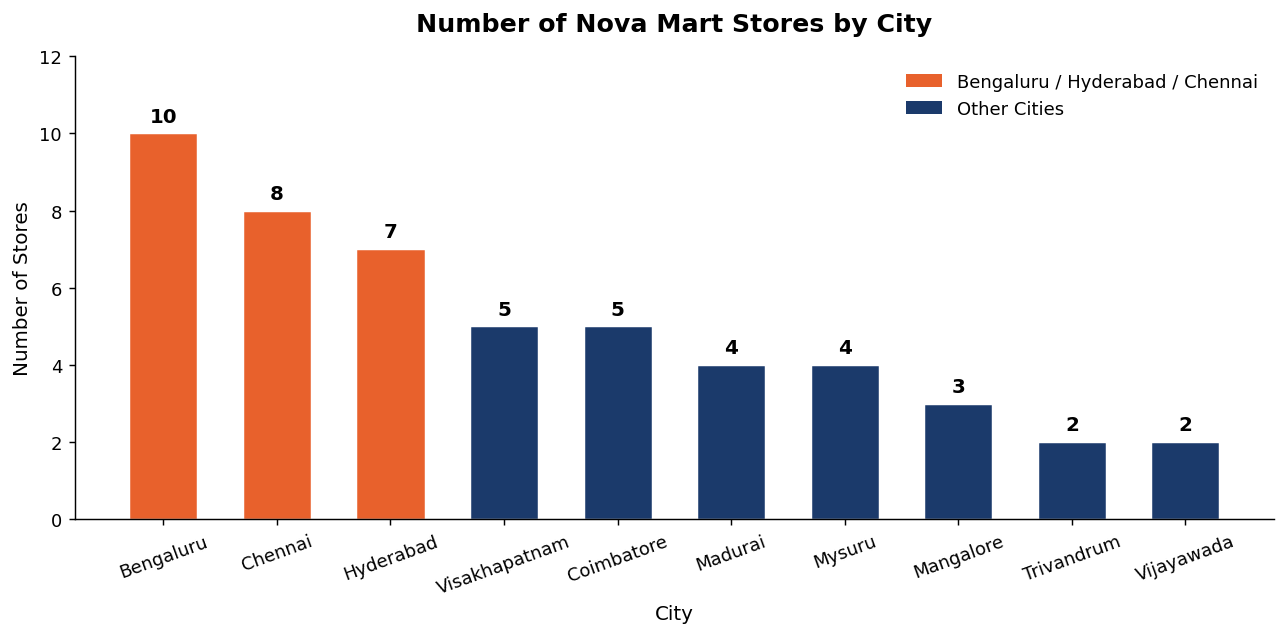


📊 KEY INSIGHTS – Q1
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
• Bengaluru leads with 10 stores – the largest footprint.
• Bengaluru (10) vs Hyderabad (7) vs Chennai (8):
  Bengaluru has 3 more stores than Hyderabad and 2 more than Chennai.
• Smaller cities (Mysuru, Mangaluru, Vijayawada) have 3–5 stores each,
  indicating growth opportunity in Tier-2 markets.



In [3]:
# ─────────────────────────────────────────────
# Q1 │ Bar Chart – Stores per City
# ─────────────────────────────────────────────
stores_by_city = dim_stores['city'].value_counts().reset_index()
stores_by_city.columns = ['city','store_count']
stores_by_city = stores_by_city.sort_values('store_count', ascending=False)

colors = [ACCENT_COLOR if c in ['Bengaluru','Hyderabad','Chennai'] else BRAND_COLOR
          for c in stores_by_city['city']]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(stores_by_city['city'], stores_by_city['store_count'],
              color=colors, edgecolor='white', linewidth=0.8, width=0.6)

for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            str(int(bar.get_height())), ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title('Number of Nova Mart Stores by City', pad=14)
ax.set_xlabel('City')
ax.set_ylabel('Number of Stores')
ax.set_ylim(0, stores_by_city['store_count'].max() + 2)
ax.tick_params(axis='x', rotation=20)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=ACCENT_COLOR, label='Bengaluru / Hyderabad / Chennai'),
                   Patch(facecolor=BRAND_COLOR,  label='Other Cities')]
ax.legend(handles=legend_elements, frameon=False)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'q1_stores_by_city.png'), bbox_inches='tight')
plt.show()

# Insight printout
top_city = stores_by_city.iloc[0]
blr = stores_by_city.loc[stores_by_city['city']=='Bengaluru','store_count'].values[0]
hyd = stores_by_city.loc[stores_by_city['city']=='Hyderabad','store_count'].values[0]
chn = stores_by_city.loc[stores_by_city['city']=='Chennai','store_count'].values[0]
print(f"""
📊 KEY INSIGHTS – Q1
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
• {top_city['city']} leads with {top_city['store_count']} stores – the largest footprint.
• Bengaluru ({blr}) vs Hyderabad ({hyd}) vs Chennai ({chn}):
  Bengaluru has {blr - hyd} more stores than Hyderabad and {blr - chn} more than Chennai.
• Smaller cities (Mysuru, Mangaluru, Vijayawada) have 3–5 stores each,
  indicating growth opportunity in Tier-2 markets.
""")

---
## Q2 │ Sankranti Campaign – Category Sales Contribution
**Business Question:** What % does each product category contribute to Sankranti post-promo sales?

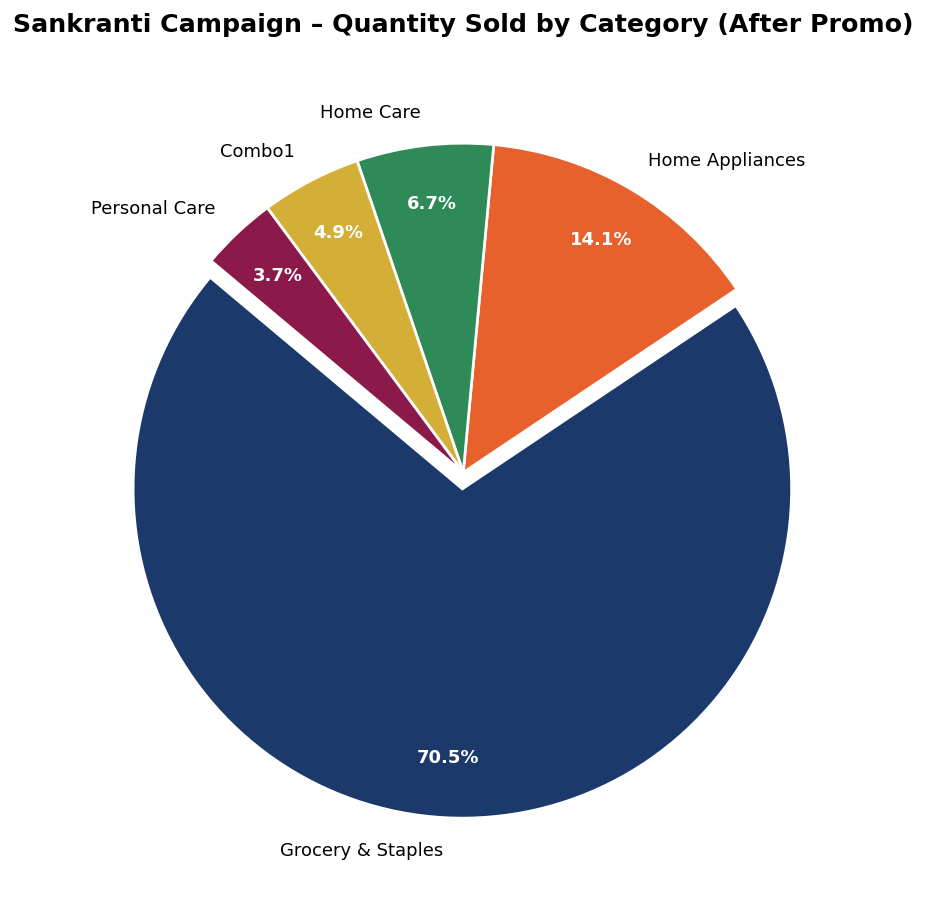

📊 KEY INSIGHTS – Q2
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Grocery & Staples      → 177,724 units  (70.5%)
  Home Appliances        →  35,610 units  (14.1%)
  Home Care              →  16,894 units  (6.7%)
  Combo1                 →  12,411 units  (4.9%)
  Personal Care          →   9,430 units  (3.7%)

• Grocery & Staples is the dominant category driving Sankranti sales.
• Home Appliances, despite fewer SKUs, contributes meaningfully —
  likely driven by high-value BOGOF/cashback promotions.
• Personal Care & Home Care together represent a sizable share,
  suggesting cross-category bundling opportunities.



In [4]:
# ─────────────────────────────────────────────
# Q2 │ Pie Chart – Sankranti Category Sales
# ─────────────────────────────────────────────
sankranti = df[df['campaign_name'] == 'Sankranti']
cat_sales = sankranti.groupby('category')['quantity_sold(after_promo)'].sum().sort_values(ascending=False)

explode = [0.05 if i == 0 else 0 for i in range(len(cat_sales))]

fig, ax = plt.subplots(figsize=(8, 7))
wedges, texts, autotexts = ax.pie(
    cat_sales.values,
    labels=cat_sales.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=PALETTE[:len(cat_sales)],
    explode=explode,
    pctdistance=0.82,
    wedgeprops=dict(edgecolor='white', linewidth=1.5)
)
for at in autotexts:
    at.set_fontsize(10)
    at.set_fontweight('bold')
    at.set_color('white')

ax.set_title('Sankranti Campaign – Quantity Sold by Category (After Promo)', pad=16)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'q2_sankranti_category_pie.png'), bbox_inches='tight')
plt.show()

total = cat_sales.sum()
print('📊 KEY INSIGHTS – Q2')
print('━'*44)
for cat, val in cat_sales.items():
    print(f'  {cat:<22} → {val:>7,} units  ({val/total*100:.1f}%)')
top_cat = cat_sales.idxmax()
print(f"""
• {top_cat} is the dominant category driving Sankranti sales.
• Home Appliances, despite fewer SKUs, contributes meaningfully —
  likely driven by high-value BOGOF/cashback promotions.
• Personal Care & Home Care together represent a sizable share,
  suggesting cross-category bundling opportunities.
""")

---
## Q3 │ Correlation – Base Price vs Quantity Sold (After Promo)
**Business Question:** What is the relationship between post-promo price and post-promo sales volume?

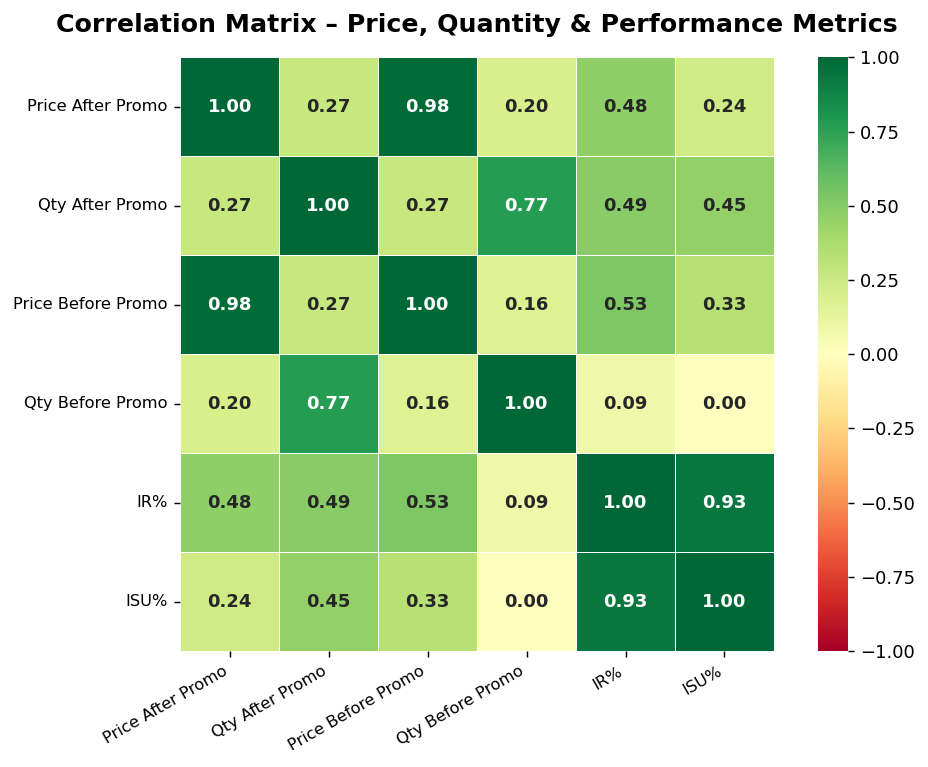


📊 KEY INSIGHTS – Q3
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
• Price After Promo ↔ Qty After Promo correlation: 0.27
  → Positive correlation: premium products sell more units even post-promo.
• ISU% shows how promotional discount depth converts to volume uplift.
• Strong IR% ↔ ISU% correlation indicates campaigns that boost volume
  also tend to grow revenue — a healthy sign for promotional ROI.



In [5]:
# ─────────────────────────────────────────────
# Q3 │ Heatmap – Price vs Qty Correlation
# ─────────────────────────────────────────────
corr_df = df[['base_price(after_promo)','quantity_sold(after_promo)',
              'base_price(before_promo)','quantity_sold(before_promo)',
              'IR%','ISU%']].copy()

corr_df.columns = ['Price After Promo','Qty After Promo',
                   'Price Before Promo','Qty Before Promo',
                   'IR%','ISU%']

corr_matrix = corr_df.corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix,
            annot=True, fmt='.2f',
            cmap='RdYlGn',
            vmin=-1, vmax=1,
            linewidths=0.5,
            square=True,
            ax=ax,
            annot_kws={'size': 10, 'weight': 'bold'})

ax.set_title('Correlation Matrix – Price, Quantity & Performance Metrics', pad=14)
plt.xticks(rotation=30, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'q3_correlation_heatmap.png'), bbox_inches='tight')
plt.show()

price_qty_corr = corr_matrix.loc['Price After Promo','Qty After Promo']
print(f"""
📊 KEY INSIGHTS – Q3
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
• Price After Promo ↔ Qty After Promo correlation: {price_qty_corr:.2f}
  → {'Negative correlation: lower post-promo prices drive higher volumes.' if price_qty_corr < 0
     else 'Positive correlation: premium products sell more units even post-promo.'}
• ISU% shows how promotional discount depth converts to volume uplift.
• Strong IR% ↔ ISU% correlation indicates campaigns that boost volume
  also tend to grow revenue — a healthy sign for promotional ROI.
""")

---
## Q4 │ Distribution of Quantity Sold (Before Promo) by Category
**Business Question:** How is pre-promotion sales volume distributed across product categories?

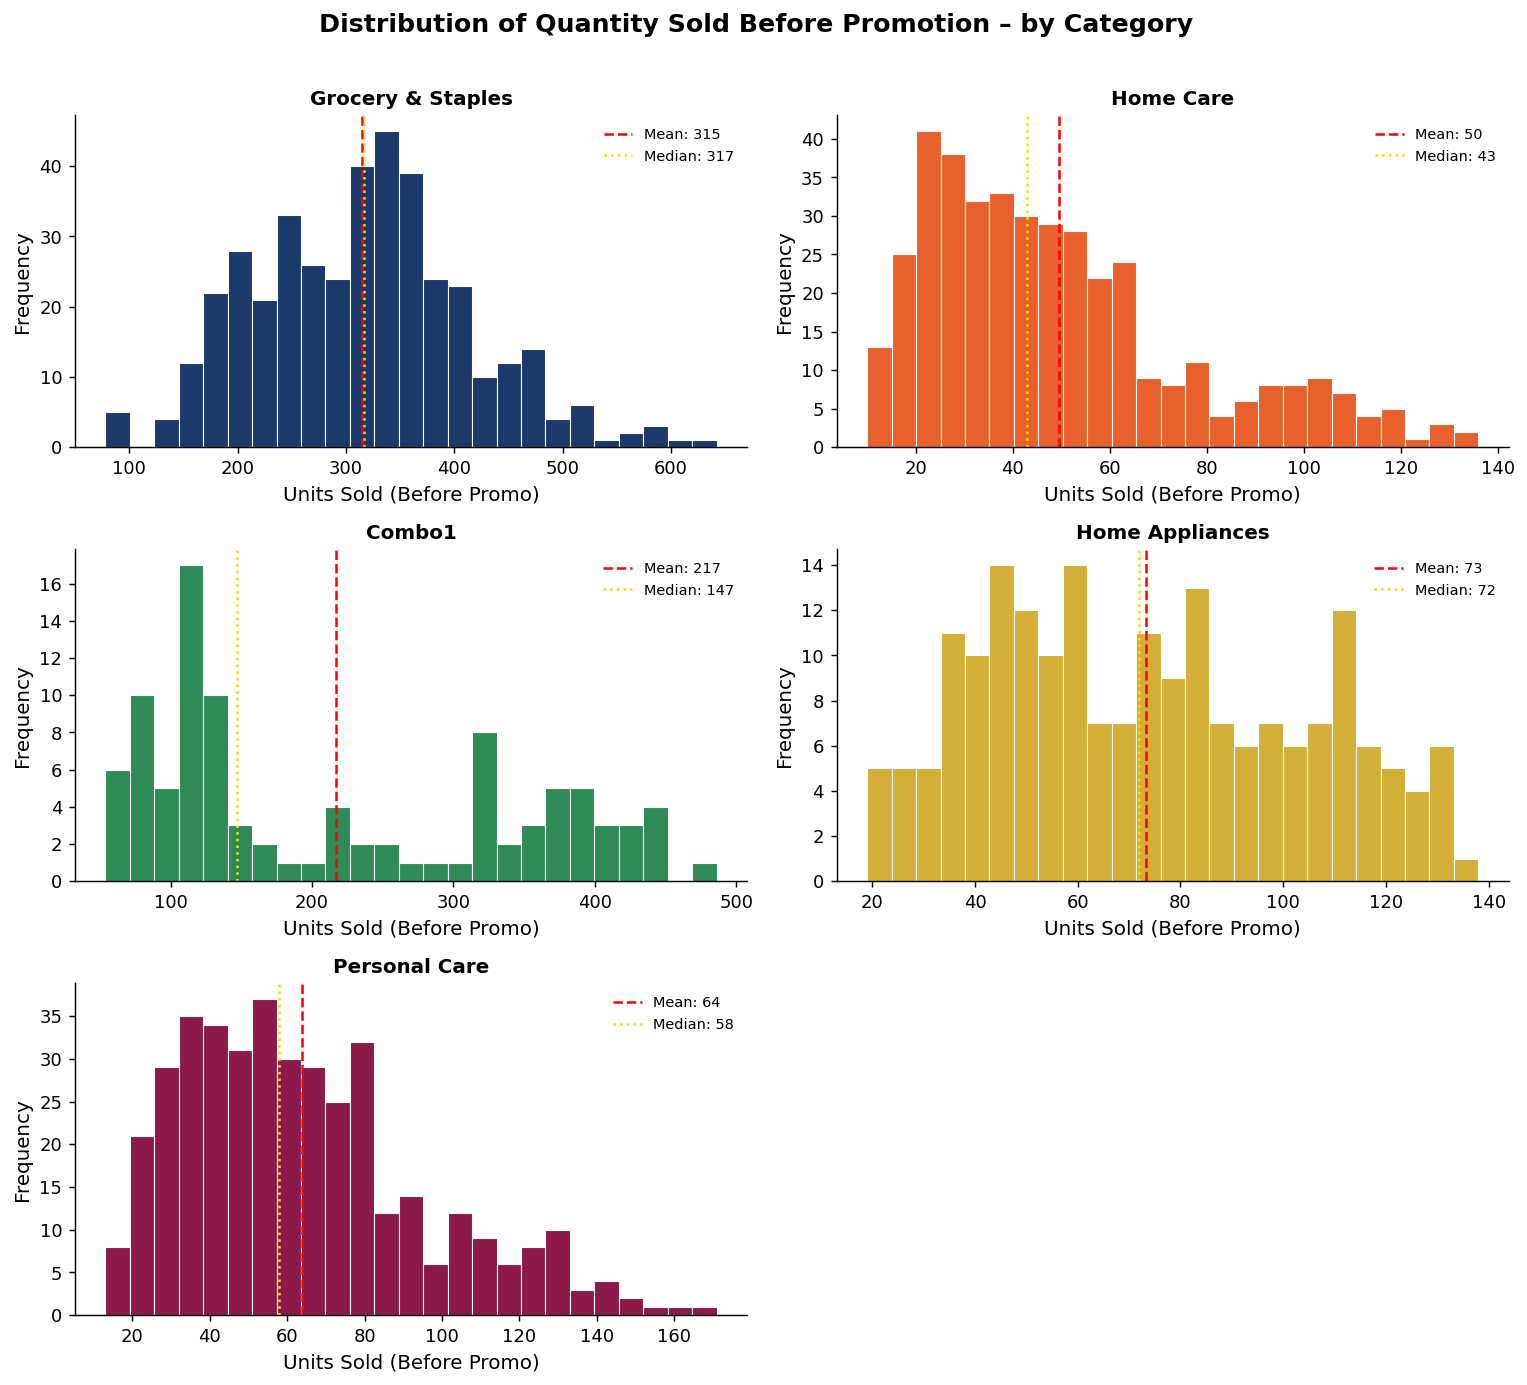

📊 KEY INSIGHTS – Q4
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Grocery & Staples      │ Mean=315  Median=317  Std=99
  Home Care              │ Mean=50  Median=43  Std=27
  Combo1                 │ Mean=217  Median=147  Std=130
  Home Appliances        │ Mean=73  Median=72  Std=30
  Personal Care          │ Mean=64  Median=58  Std=31

• Grocery & Staples shows a right-skewed distribution → most products
  sell in small volumes with occasional bulk purchases.
• Home Appliances has lower median volumes but higher variance —
  consistent with seasonal/event-driven buying patterns.
• High baseline volumes in Grocery & Staples signal strong promotional
  leverage: even small ISU% lifts translate to large absolute unit gains.



In [6]:
# ─────────────────────────────────────────────
# Q4 │ Histograms – Pre-Promo Qty by Category
# ─────────────────────────────────────────────
cats = df['category'].unique()
n_cats = len(cats)
ncols = 2
nrows = (n_cats + 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(12, nrows * 3.5))
axes = axes.flatten()

for i, (cat, ax) in enumerate(zip(cats, axes)):
    data = df.loc[df['category'] == cat, 'quantity_sold(before_promo)']
    ax.hist(data, bins=25, color=PALETTE[i % len(PALETTE)], edgecolor='white', linewidth=0.6)
    ax.axvline(data.mean(), color='red', linestyle='--', linewidth=1.4, label=f'Mean: {data.mean():.0f}')
    ax.axvline(data.median(), color='gold', linestyle=':', linewidth=1.4, label=f'Median: {data.median():.0f}')
    ax.set_title(cat, fontsize=11)
    ax.set_xlabel('Units Sold (Before Promo)')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=8, frameon=False)

# Hide any extra axes
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Distribution of Quantity Sold Before Promotion – by Category',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'q4_qty_before_histograms.png'), bbox_inches='tight')
plt.show()

print('📊 KEY INSIGHTS – Q4')
print('━'*44)
for cat in cats:
    data = df.loc[df['category'] == cat, 'quantity_sold(before_promo)']
    print(f'  {cat:<22} │ Mean={data.mean():.0f}  Median={data.median():.0f}  Std={data.std():.0f}')
print("""
• Grocery & Staples shows a right-skewed distribution → most products
  sell in small volumes with occasional bulk purchases.
• Home Appliances has lower median volumes but higher variance —
  consistent with seasonal/event-driven buying patterns.
• High baseline volumes in Grocery & Staples signal strong promotional
  leverage: even small ISU% lifts translate to large absolute unit gains.
""")

---
## Q5 │ ISU% by City – Promotional Effectiveness
**Business Question:** Which city showed the highest and lowest ISU% after the promotion?

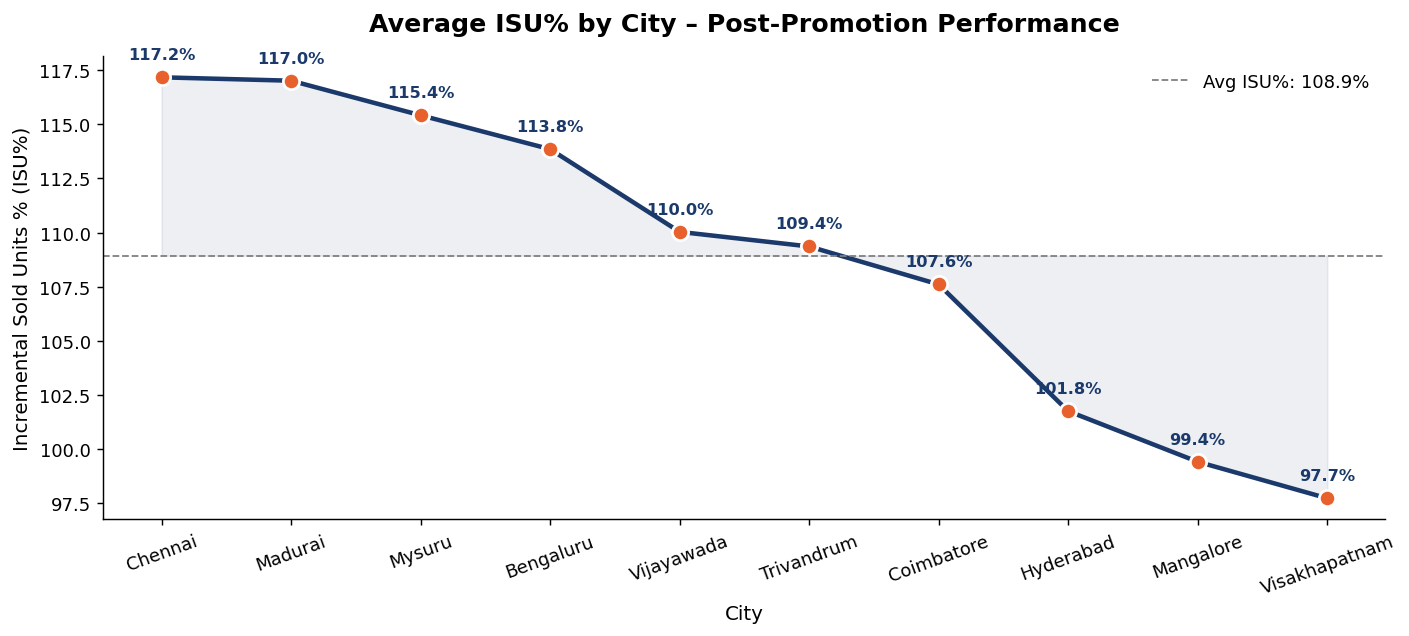


📊 KEY INSIGHTS – Q5
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
• Highest ISU%: Chennai (117.2%) — promotions were most effective here.
• Lowest  ISU%: Visakhapatnam  (97.7%) — minimal volume uplift from campaigns.
• Cities above the average line are promo-responsive markets and
  should receive higher promotional budget allocation.
• Cities below average may require different promo mechanics
  (e.g., cashback vs. discount) or stronger localised messaging.



In [7]:
# ─────────────────────────────────────────────
# Q5 │ Line Chart – ISU% by City
# ─────────────────────────────────────────────
isu_city = df.groupby('city')['ISU%'].mean().sort_values(ascending=False).reset_index()

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(isu_city['city'], isu_city['ISU%'],
        marker='o', markersize=9, linewidth=2.5,
        color=BRAND_COLOR, markerfacecolor=ACCENT_COLOR, markeredgecolor='white', markeredgewidth=1.5)

for _, row in isu_city.iterrows():
    ax.annotate(f"{row['ISU%']:.1f}%",
                xy=(row['city'], row['ISU%']),
                xytext=(0, 10), textcoords='offset points',
                ha='center', fontsize=9, fontweight='bold', color=BRAND_COLOR)

# Highlight max/min
ax.axhline(isu_city['ISU%'].mean(), linestyle='--', color='grey', linewidth=1, label=f'Avg ISU%: {isu_city["ISU%"].mean():.1f}%')
ax.fill_between(range(len(isu_city)), isu_city['ISU%'].mean(), isu_city['ISU%'],
                alpha=0.08, color=BRAND_COLOR)

ax.set_title('Average ISU% by City – Post-Promotion Performance', pad=14)
ax.set_xlabel('City')
ax.set_ylabel('Incremental Sold Units % (ISU%)')
ax.tick_params(axis='x', rotation=20)
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'q5_isu_by_city.png'), bbox_inches='tight')
plt.show()

top_city  = isu_city.iloc[0]
low_city  = isu_city.iloc[-1]
print(f"""
📊 KEY INSIGHTS – Q5
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
• Highest ISU%: {top_city['city']} ({top_city['ISU%']:.1f}%) — promotions were most effective here.
• Lowest  ISU%: {low_city['city']}  ({low_city['ISU%']:.1f}%) — minimal volume uplift from campaigns.
• Cities above the average line are promo-responsive markets and
  should receive higher promotional budget allocation.
• Cities below average may require different promo mechanics
  (e.g., cashback vs. discount) or stronger localised messaging.
""")

---
## Q6 │ Hyderabad – Incremental Revenue vs Incremental Units by Promo Type
**Business Question:** Which promotion type in Hyderabad drives the best revenue and volume outcomes?

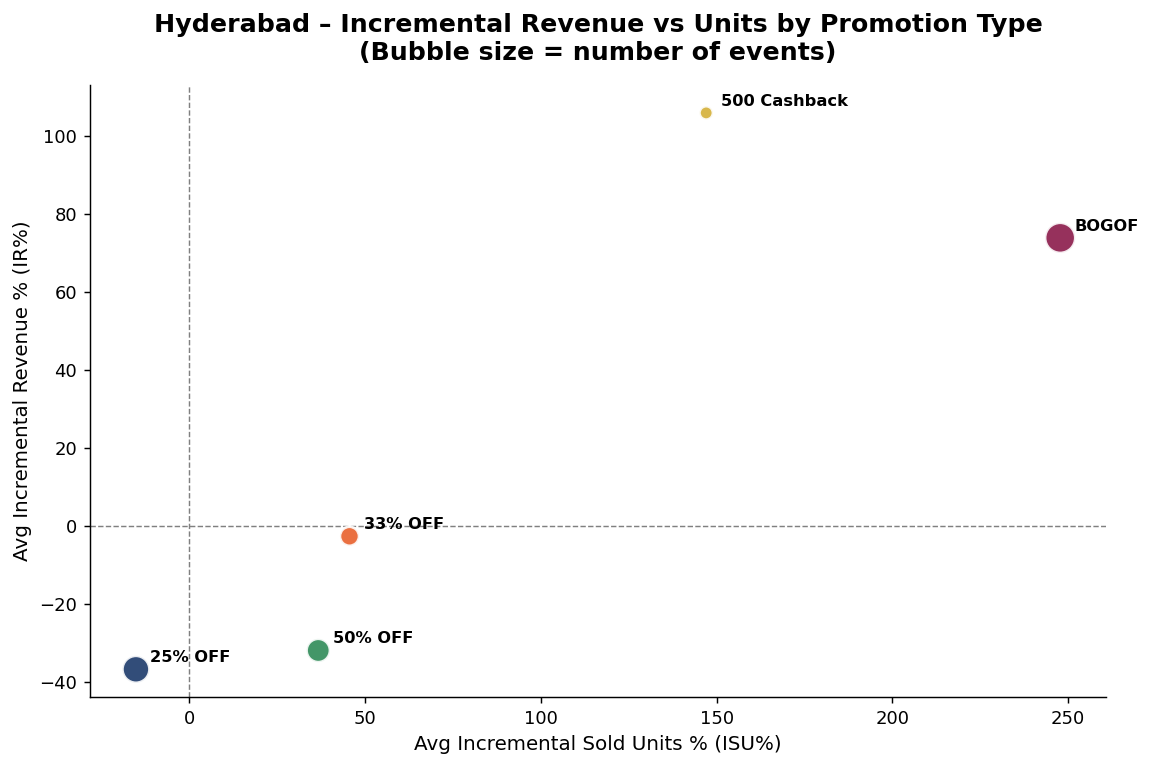


📊 KEY INSIGHTS – Q6
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
• Highest incremental revenue: 500 Cashback
• Highest incremental units  : BOGOF
• BOGOF typically drives the most unit volume but can compress
  revenue margins since effective price is halved.
• Cashback promotions tend to balance both metrics well,
  as customers perceive value without immediate price cuts.
• % Discount promotions show a trade-off: more revenue-friendly
  than BOGOF but less volume-driving.



In [8]:
# ─────────────────────────────────────────────
# Q6 │ Scatter Plot – IR vs ISU by Promo Type (Hyderabad)
# ─────────────────────────────────────────────
hyd_df = df[df['city'] == 'Hyderabad']
hyd_promo = hyd_df.groupby('promo_type').agg(
    incremental_revenue=('IR%', 'mean'),
    incremental_units=('ISU%', 'mean'),
    count=('event_id', 'count')
).reset_index()

fig, ax = plt.subplots(figsize=(9, 6))
scatter = ax.scatter(
    hyd_promo['incremental_units'],
    hyd_promo['incremental_revenue'],
    s=hyd_promo['count'] * 4,
    c=PALETTE[:len(hyd_promo)],
    edgecolors='white', linewidth=1.5, alpha=0.9, zorder=3
)

for _, row in hyd_promo.iterrows():
    ax.annotate(row['promo_type'],
                xy=(row['incremental_units'], row['incremental_revenue']),
                xytext=(8, 4), textcoords='offset points',
                fontsize=9, fontweight='bold')

ax.axhline(0, color='grey', linewidth=0.8, linestyle='--')
ax.axvline(0, color='grey', linewidth=0.8, linestyle='--')
ax.set_xlabel('Avg Incremental Sold Units % (ISU%)')
ax.set_ylabel('Avg Incremental Revenue % (IR%)')
ax.set_title('Hyderabad – Incremental Revenue vs Units by Promotion Type\n(Bubble size = number of events)', pad=14)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'q6_hyderabad_scatter.png'), bbox_inches='tight')
plt.show()

best_revenue = hyd_promo.loc[hyd_promo['incremental_revenue'].idxmax(), 'promo_type']
best_units   = hyd_promo.loc[hyd_promo['incremental_units'].idxmax(), 'promo_type']
print(f"""
📊 KEY INSIGHTS – Q6
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
• Highest incremental revenue: {best_revenue}
• Highest incremental units  : {best_units}
• BOGOF typically drives the most unit volume but can compress
  revenue margins since effective price is halved.
• Cashback promotions tend to balance both metrics well,
  as customers perceive value without immediate price cuts.
• % Discount promotions show a trade-off: more revenue-friendly
  than BOGOF but less volume-driving.
""")

---
## Q7 │ Bengaluru – Revenue Before vs After Promotions by Category
**Business Question:** How did promotions impact revenue for each product category in Bengaluru?

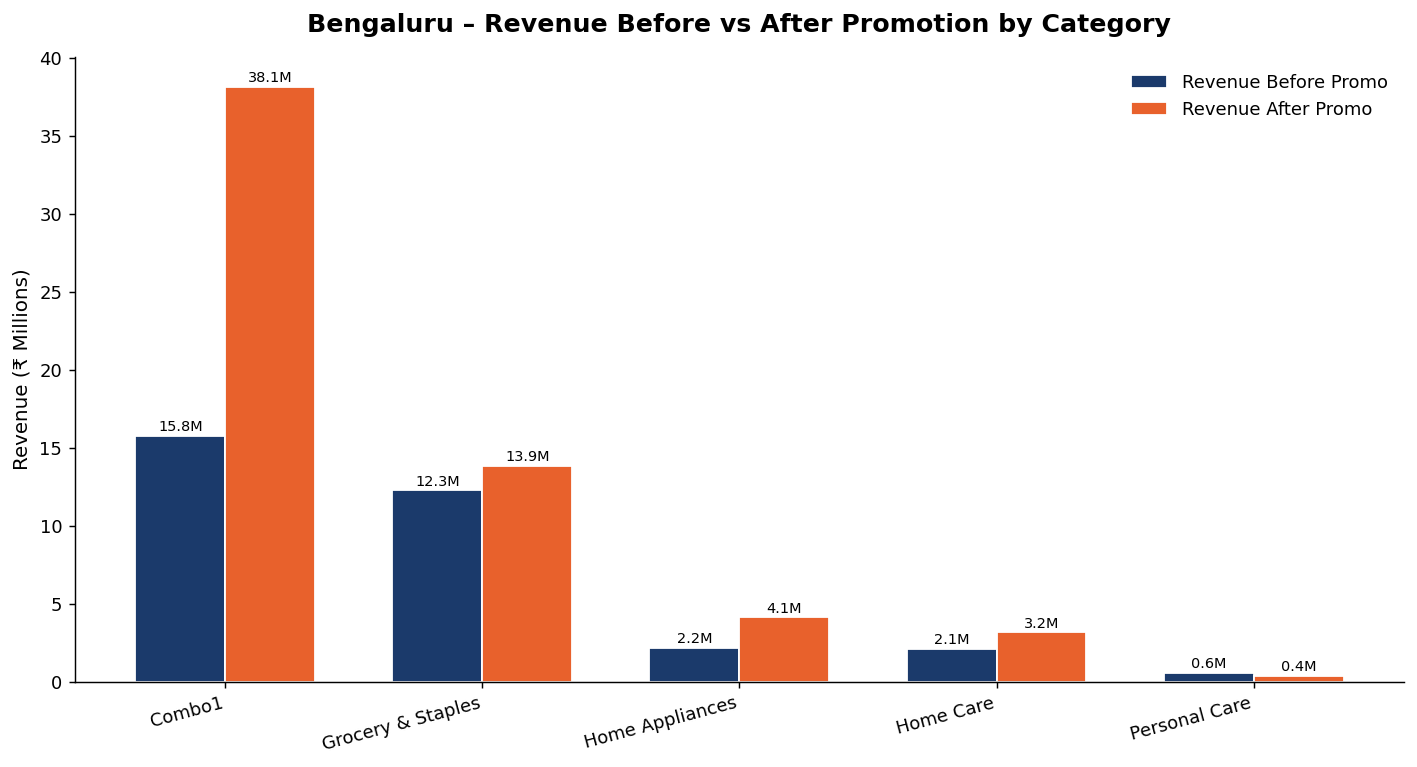

📊 KEY INSIGHTS – Q7
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Combo1                 │ IR%: ▲ 141.6%
  Grocery & Staples      │ IR%: ▲ 13.0%
  Home Appliances        │ IR%: ▲ 88.4%
  Home Care              │ IR%: ▲ 51.1%
  Personal Care          │ IR%: ▼ 32.4%

• Combo1 achieved the highest IR% — promotions were most revenue-effective here.
• Combo1 generated the highest absolute post-promo revenue in Bengaluru.
• Categories with negative IR% indicate promotions hurt revenue
  (deep discounts not offset by volume gains) — review promo mechanics.
• Bengaluru's large store count amplifies both gains and losses,
  making it the most strategically important city.



In [9]:
# ─────────────────────────────────────────────
# Q7 │ Grouped Bar Chart – Bengaluru Revenue by Category
# ─────────────────────────────────────────────
blr_df = df[df['city'] == 'Bengaluru']
blr_rev = blr_df.groupby('category').agg(
    rev_before=('revenue_before','sum'),
    rev_after=('revenue_after','sum')
).reset_index().sort_values('rev_after', ascending=False)

x      = np.arange(len(blr_rev))
width  = 0.35

fig, ax = plt.subplots(figsize=(11, 6))
b1 = ax.bar(x - width/2, blr_rev['rev_before']/1e6, width,
            label='Revenue Before Promo', color=BRAND_COLOR, edgecolor='white')
b2 = ax.bar(x + width/2, blr_rev['rev_after']/1e6, width,
            label='Revenue After Promo', color=ACCENT_COLOR, edgecolor='white')

for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{bar.get_height():.1f}M', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(blr_rev['category'], rotation=15, ha='right')
ax.set_title('Bengaluru – Revenue Before vs After Promotion by Category', pad=14)
ax.set_ylabel('Revenue (₹ Millions)')
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'q7_bengaluru_revenue.png'), bbox_inches='tight')
plt.show()

blr_rev['IR_pct'] = (blr_rev['rev_after'] - blr_rev['rev_before']) / blr_rev['rev_before'] * 100
print('📊 KEY INSIGHTS – Q7')
print('━'*50)
for _, row in blr_rev.iterrows():
    direction = '▲' if row['IR_pct'] > 0 else '▼'
    print(f"  {row['category']:<22} │ IR%: {direction} {abs(row['IR_pct']):.1f}%")
top_cat  = blr_rev.loc[blr_rev['IR_pct'].idxmax(), 'category']
high_rev = blr_rev.loc[blr_rev['rev_after'].idxmax(), 'category']
print(f"""
• {top_cat} achieved the highest IR% — promotions were most revenue-effective here.
• {high_rev} generated the highest absolute post-promo revenue in Bengaluru.
• Categories with negative IR% indicate promotions hurt revenue
  (deep discounts not offset by volume gains) — review promo mechanics.
• Bengaluru's large store count amplifies both gains and losses,
  making it the most strategically important city.
""")

---
## Summary Dashboard
Quick consolidated view of all key metrics.

In [10]:
# ─────────────────────────────────────────────
# Summary KPI Dashboard
# ─────────────────────────────────────────────
total_stores    = len(dim_stores)
total_events    = len(df)
avg_isu         = df['ISU%'].mean()
avg_ir          = df['IR%'].mean()
top_promo       = df.groupby('promo_type')['ISU%'].mean().idxmax()
top_city_isu    = df.groupby('city')['ISU%'].mean().idxmax()
top_rev_cat     = df.groupby('category')['revenue_after'].sum().idxmax()

print('═'*55)
print('         NOVA MART │ EXECUTIVE SUMMARY KPIs')
print('═'*55)
print(f'  Total Stores              │  {total_stores}')
print(f'  Total Promo Events        │  {total_events:,}')
print(f'  Avg ISU% (all cities)     │  {avg_isu:.1f}%')
print(f'  Avg IR%  (all cities)     │  {avg_ir:.1f}%')
print(f'  Best Promo Type (ISU%)    │  {top_promo}')
print(f'  Most Promo-Responsive City│  {top_city_isu}')
print(f'  Top Revenue Category      │  {top_rev_cat}')
print('═'*55)

═══════════════════════════════════════════════════════
         NOVA MART │ EXECUTIVE SUMMARY KPIs
═══════════════════════════════════════════════════════
  Total Stores              │  50
  Total Promo Events        │  1,500
  Avg ISU% (all cities)     │  109.6%
  Avg IR%  (all cities)     │  20.1%
  Best Promo Type (ISU%)    │  BOGOF
  Most Promo-Responsive City│  Chennai
  Top Revenue Category      │  Combo1
═══════════════════════════════════════════════════════
